# Naive Bayes Algorithm

## What is Naive Bayes?

Naive Bayes is a **probabilistic classification algorithm** based on Bayes' Theorem, with the "naive" assumption that all features are **independent of each other** given the class label. Despite this oversimplification, it performs remarkably well in practice — especially for text classification tasks.


## Bayes' Theorem

At its core, the algorithm applies:

$$P(Class | Features) = \frac{P(Features | Class) \cdot P(Class)}{P(Features)}$$

In plain terms:

> *"Given what I observe, what is the probability this belongs to a certain class?"*


## The "Naive" Assumption

Features are assumed to be **conditionally independent**, meaning:

$$P(x_1, x_2, ..., x_n | C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

This makes computation extremely fast — even with thousands of features.


## Types of Naive Bayes

| Type | Best For | Feature Distribution |
|---|---|---|
| **Gaussian NB** | Continuous data | Normal distribution |
| **Multinomial NB** | Text / word counts | Count data |
| **Bernoulli NB** | Binary features | 0/1 presence |
| **Complement NB** | Imbalanced text data | Count data |


## How It Works — Step by Step

**1. Training Phase**
- Calculate **prior probability** P(Class) for each class
- Calculate **likelihood** P(feature | class) for each feature per class

**2. Prediction Phase**
- For a new input, compute the posterior probability for each class
- Pick the class with the **highest posterior**

$$\hat{y} = \arg\max_c \ P(C=c) \prod_{i=1}^{n} P(x_i | C=c)$$

## Pros & Cons

| Advantages |  Disadvantages |
|---|---|
| Very fast to train & predict | Independence assumption rarely holds |
| Works well with small data | Poor probability estimates |
| Handles high dimensions well | Struggles with feature correlations |
| Great for text/NLP tasks | Zero-frequency problem (without smoothing) |
| Simple & interpretable | Not ideal for complex relationships |


## Comparison with Other Classifiers

| Algorithm | Speed | Interpretability | Accuracy (text) |
|---|---|---|---|
| Naive Bayes |  Very Fast |  High |  Good |
| Logistic Regression | Fast | Medium | Good |
| SVM | Medium | Low | Very Good |
| Random Forest | Slow | Low | Excellent |
| Neural Network | Very Slow | Very Low | Best |


## Key Takeaway

> Naive Bayes is a **fast, simple, and surprisingly effective** algorithm — especially for text classification. It's often the first model you should try when working with NLP tasks.

The notebook begins by importing essential Python libraries required for building a text classification model and performing data analysis.

[NumPy](https://numpy.org/) is used for numerical computations and handling arrays and mathematical operations.  
[Pandas](https://pandas.pydata.org/) is used for data manipulation and working with structured datasets like DataFrames.  
[Matplotlib](https://matplotlib.org/) is used for creating basic plots and visualizations.  
[Seaborn](https://seaborn.pydata.org/) enhances data visualization by providing advanced and more visually appealing statistical plots.  

For text processing, [NLTK](https://www.nltk.org/) is used to clean and preprocess text data, including removing stopwords and applying lemmatization.

For machine learning, [Scikit-learn](https://scikit-learn.org/) provides tools for splitting data, building models, and evaluating performance. Text data is converted into numerical features using TF-IDF (TfidfVectorizer), and classification is performed using the Multinomial Naive Bayes algorithm.

These libraries together form the foundation for preprocessing text, extracting features, training a model, and evaluating its performance in a complete NLP pipeline.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

## Reading Data from CSV

In this step, the dataset is loaded into the notebook using Pandas. The `read_csv` function reads the CSV file and stores it in a DataFrame named `df`. Using `df.head()` displays the first few records, allowing an initial look at the structure and columns of the data before further analysis.

The dataset used is the Heart Disease Dataset, which can be found here: [Click here](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

In [21]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [22]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.isnull().sum()

,0
v1,0
v2,0


In [24]:
rows , columns = df.shape
rows , columns

(5572, 2)

In [25]:
df.drop_duplicates(inplace=True)
rows , columns = df.shape
rows , columns

(5169, 2)

In [26]:
df.describe()

,v1,v2
count,5169,5169
unique,2,5169
top,ham,Rofl. Its true to its name
freq,4516,1


## Text Preprocessing

In this step, text data is cleaned and prepared for machine learning using NLTK.

The `nltk.download('stopwords')` and `nltk.download('wordnet')` commands ensure that required linguistic resources are available for preprocessing.

A `WordNetLemmatizer` is initialized to reduce words to their base or root form (e.g., "running" → "run").

The `preprocess` function performs the following operations:
- Converts text to lowercase for uniformity  
- Removes non-alphabetic characters using regular expressions  
- Splits text into individual words (tokenization)  
- Removes common stopwords (e.g., "the", "is", "and")  
- Applies lemmatization to normalize words  

Finally, the cleaned text is stored in a new column `clean_text` by applying the preprocessing function to the original text column `v2`.

This step helps improve model performance by reducing noise and standardizing the input text.

In [27]:
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords.words('english')]
    return ' '.join(words)

df['clean_text'] = df['v2'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [28]:
df['label'] = df['v1'].map({'ham': 0, 'spam': 1})

In [29]:
df

,v1,v2,clean_text,label
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though,0
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,nd time tried contact u u pound prize claim ea...,1
5568,ham,Will Ì_ b going to esplanade fr home?,b going esplanade fr home,0
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood suggestion,0
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...,0


In [30]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## TF-IDF (Feature Extraction)

TF-IDF converts text into numerical vectors by measuring word importance.

$$
tf\text{-}idf(t, d) = tf(t, d) \cdot \log\left(\frac{N}{df(t)}\right)
$$

Where:

* ( tf(t,d) ): frequency of term ( t ) in document ( d )
* ( df(t) ): number of documents containing term ( t )
* ( N ): total number of documents


$$
\hat{y} = \arg\max_c \ P(C) \prod_{i=1}^{n} P(x_i | C)
$$

In [31]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', lowercase=True)),
    ('nb',    MultinomialNB())
])

In [32]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('nb', MultinomialNB())])

## Prediction Results and Probability Analysis

In this step, the trained model is used to generate predictions and probability scores for the test data.

The `predict_proba()` function returns the probability of each class (e.g., spam or ham) for every input message.

A new DataFrame `results_df` is created to combine:
- Original message (`X_test`)  
- Actual label (`y_test`)  
- Predicted label (`y_pred`)  
- Spam probability (`y_probs[:, 1]`)  
- Ham probability (`y_probs[:, 0]`)  

This structured view makes it easier to compare predictions with actual values and analyze model confidence.

Using `results_df.head()` displays the first few rows of the results for quick inspection.

In [33]:
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)

results_df = pd.DataFrame({
    'Message': X_test.values,
    'Actual Label': y_test.values,
    'Predicted Label': y_pred,
    'Spam Probability': y_probs[:, 1],
    'Ham Probability': y_probs[:, 0]
})

results_df.head()

,Message,Actual Label,Predicted Label,Spam Probability,Ham Probability
0,u download fring app,0,0,0.244272,0.755728
1,pas dis ur contact n see wat u get red luv wid...,0,0,0.062915,0.937085
2,ok,0,0,0.005898,0.994102
3,film ill call later,0,0,0.012001,0.987999
4,sorry left phone upstairs ok might hectic woul...,0,0,0.038481,0.961519


## Model Accuracy Evaluation

In this step, the trained model is evaluated on both training and testing datasets.

The `predict()` function is used to generate predictions for:
- Training data (`X_train`)  
- Testing data (`X_test`)  

Accuracy is calculated using:

$$
Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}
$$

Results:
- Training Accuracy: 0.9758  
- Testing Accuracy: 0.9681  

The high accuracy on both training and testing data indicates that the model is performing well and generalizing effectively without significant overfitting.

In [34]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)
print("Training Accuracy :", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy :", accuracy_score(y_test, y_test_pred))

Training Accuracy : 0.9758162031438936
Testing Accuracy : 0.9680851063829787


In [35]:
msg = ["Congratulations! You've won a free lottery ticket. Call now!"]

# Prediction
prediction = pipeline.predict(msg)[0]
probs = pipeline.predict_proba(msg)[0]

# Convert label to readable form
label = "Spam" if prediction == 1 else "Ham"

# Print formatted output
print("Message:", msg[0])
print("Prediction:", label)
print(f"Ham Probability: {probs[0]*100:.2f}%")
print(f"Spam Probability: {probs[1]*100:.2f}%")

Message: Congratulations! You've won a free lottery ticket. Call now!
Prediction: Ham
Ham Probability: 80.52%
Spam Probability: 19.48%


## Confusion Matrix Visualization

In this step, a confusion matrix is used to evaluate the performance of the classification model.

The confusion matrix compares the actual labels with the predicted labels and summarizes the results into four categories:

- `True Positives (TP)`: Correctly predicted spam messages  
- `True Negatives (TN)`: Correctly predicted ham messages  
- `False Positives (FP)`: Ham messages incorrectly predicted as spam  
- `False Negatives (FN)`: Spam messages incorrectly predicted as ham  

The confusion matrix is visualized using a heatmap with :contentReference[oaicite:0]{index=0}, making it easier to interpret the model's performance.

This visualization helps identify how well the model distinguishes between spam and ham messages and highlights any misclassification patterns.

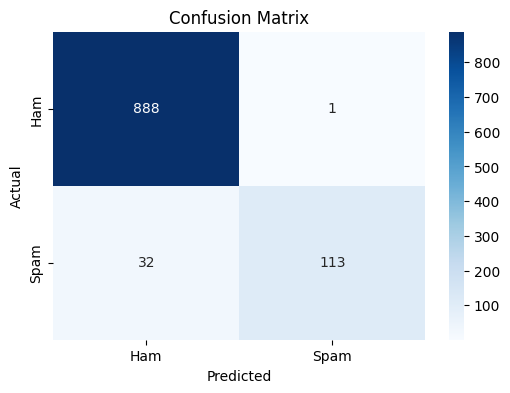

In [36]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve and AUC Score

In this step, the model's performance is evaluated using the ROC (Receiver Operating Characteristic) curve and AUC (Area Under the Curve).

The `predict_proba()` function is used to obtain the probability of the positive class (spam). These probabilities are then used to compute:

- False Positive Rate (FPR)  
- True Positive Rate (TPR)  

The ROC curve plots TPR against FPR at different threshold values.

AUC is calculated as:

$$
AUC = \int_{0}^{1} TPR(FPR)\, d(FPR)
$$

Output:
- AUC Score: (value of `roc_auc`)

A higher AUC score (closer to 1) indicates better model performance and stronger ability to distinguish between spam and ham messages.

In [37]:
y_probs = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9851440983670144


## ROC Curve Visualization

In this step, the ROC curve is plotted to visualize the model's performance.

The curve is created by plotting:
- True Positive Rate (TPR) on the y-axis  
- False Positive Rate (FPR) on the x-axis  

A diagonal dashed line represents a random classifier for comparison.

The ROC curve helps evaluate how well the model distinguishes between classes at different threshold values.

The AUC score is included in the legend to summarize overall performance:
- A higher AUC indicates better classification ability  
- A curve closer to the top-left corner represents a stronger model  

This visualization provides an intuitive understanding of the trade-off between sensitivity and specificity.

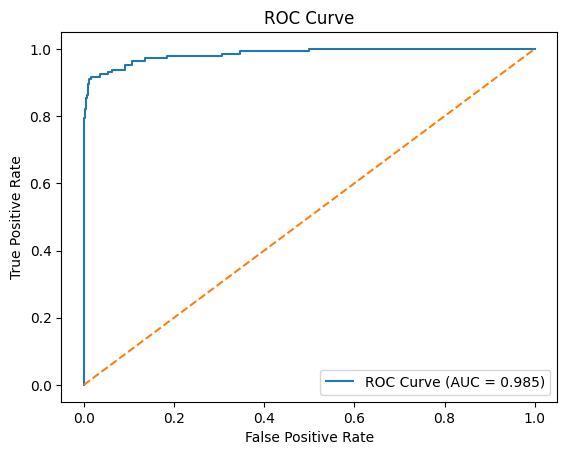

In [38]:
plt.figure()

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()